# Week 7: Feature Selection Methods

## Learning Objectives

1. Understand why feature selection matters: Fewer, better features often outperform using all features
2. Apply Lasso regression: L1 penalty that shrinks unimportant coefficients to exactly zero
3. Apply Elastic Net: Combine Lasso (L1) and Ridge (L2) penalties for more stable selection
4. Use MRMR: A filter method that picks features with high relevance and low redundancy
5. Rank features with Random Forest: Tree-based feature importance scores
6. Compare selection methods: Observe how different methods pick different subsets
7. Kaggle Challenge: Use feature selection + your best model to maximize test accuracy

In [1]:
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

## Train/Test Split

We split data before any feature selection. This is critical:

- Feature selection must only see training data — otherwise we leak test information
- `stratify=y` ensures both splits have the same class ratio (~68% survived, ~32% died)
- `random_state=42` makes results reproducible

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [3]:
feature_names = X.columns
feature_names

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='str')

## Normalize Data

Why normalize before Lasso/Elastic Net?

Lasso and Elastic Net use coefficient magnitudes to decide which features to drop. If features are on different scales (e.g., `platelets` ≈ 200,000 vs `age` ≈ 60), large-scale features will dominate unfairly.

Rule: Always fit the scaler on training data only (`fit_transform`), then apply to test data (`transform`). Fitting on test data would leak information.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Why Feature Selection?

With 11 features and only 299 patients, some features are:
- Irrelevant — no real relationship with death (e.g., `sex`, `smoking` in this dataset)
- Redundant — highly correlated with another feature (add noise, not information)

Benefits of removing these features:
- Reduce overfitting (model learns noise from irrelevant features)
- Faster training and inference
- More interpretable models

Feature Selection Method Comparision:

| Type | Method | How it selects |
|------|--------|----------------|
| Embedded | Lasso | Penalize coefficients during model training |
| Embedded | Elastic Net | Like Lasso but with added Ridge stability |
| Filter | MRMR | Statistical score (relevance - redundancy) |
| Embedded | Random Forest | Feature importance from tree splits |

## Lasso

Lasso (Least Absolute Shrinkage and Selection Operator) fits a linear model with an L1 penalty:

$$\text{Loss} = \text{MSE} + \alpha \sum |\beta_i|$$

The penalty pushes small coefficients exactly to zero, effectively removing those features:

- α (alpha) controls the strength of the penalty: Larger α = more features dropped
- `LassoCV` automatically finds the best α using 5-fold cross-validation

Why it works for feature selection: Unlike Ridge (L2 penalty, which shrinks but never zeros), L1 creates sparse solutions — perfect for identifying which features to keep.

Two thresholds below:
- `B2 != 0` — any feature Lasso decided to keep at all
- `abs(B2) >= 0.02` — only features with meaningful coefficient size (stricter)

In [5]:
from sklearn import linear_model
model = linear_model.LassoCV(cv=5)
lasso_regression = model.fit(X_train,y_train)
B2 = lasso_regression.coef_
B2

array([ 0.0409842 ,  0.0155569 ,  0.0435928 ,  0.01277368, -0.10970532,
        0.01432047, -0.        ,  0.12604567, -0.01690006,  0.        ,
        0.        ])

In [6]:
selected_features = feature_names[B2 != 0]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium'],
      dtype='str')

In [7]:
selected_features = feature_names[abs(B2) >= 0.02]
selected_features

Index(['age', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine'],
      dtype='str')

## Elastic Net

Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties:

$$\text{Loss} = \text{MSE} + \left[ \rho \sum |\beta_i| + (1-\rho) \sum \beta_i^2 \right]$$

- `l1_ratio` (ρ) = 0.5 means equal weight on L1 and L2
- L1 part drives some coefficients to zero (selection)
- L2 part stabilizes correlated features (Ridge keeps them together rather than randomly dropping one)

Why use Elastic Net over Lasso?

| Situation | Lasso | Elastic Net |
|-----------|-------|-------------|
| Many correlated features | Randomly drops one | Tends to keep groups |
| High-dimensional data | Good | Better |
| Small dataset | Can be unstable | More stable |

`ElasticNetCV` cross-validates both α and l1_ratio automatically.

In [8]:
import numpy as np

from sklearn.linear_model import ElasticNetCV
enet_cv = ElasticNetCV(
    l1_ratio=0.5,
    alphas=100,
    cv=5,
    max_iter=1000,
    tol=1e-7,
    n_jobs=-1
)

enet_cv.fit(X_train, y_train)
selected_features = feature_names[enet_cv.coef_ != 0]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium', 'smoking'],
      dtype='str')

In [9]:
selected_features = feature_names[abs(enet_cv.coef_) >= 0.02]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine', 'serum_sodium'],
      dtype='str')

## MRMR (Minimum Redundancy Maximum Relevance)

Unlike Lasso/Elastic Net, which fits a linear models, MRMR is a filter method: It uses statistics to score features independently of any model.

For each candidate feature, MRMR computes:

$$\text{Score} = \underbrace{\text{Relevance}(f, y)}_{\text{correlation with target}} - \underbrace{\text{Redundancy}(f, S)}_{\text{avg. correlation with already selected features}}$$

It greedily selects features one at a time, always picking the one with the highest score.

Key parameter `K`: How many features to select

Why it works: A feature that strongly predicts the target but overlaps heavily with another selected feature adds little value. MRMR explicitly penalizes this overlap so you get a diverse, informative set.

**Note**: The code re-splits and re-scales data here to ensure MRMR receives a clean DataFrame with column names (required by the `mrmr` library).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y,random_state=42)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)

X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

from mrmr import mrmr_classif

selected_features = mrmr_classif(X=X_train, y=y_train, K=2) # select the top 2 features
selected_features

100%|██████████| 2/2 [00:00<00:00, 11.51it/s]


['serum_creatinine', 'ejection_fraction']

## Random Forest Feature Importance

Random Forest measures importance by tracking how much each feature reduces impurity (Gini impurity or entropy) across all splits in all trees:

- A feature that appears high in many trees and causes large impurity reductions = High importance
- Features never used for splits = Importance ≈ 0

Why use Random Forest for feature selection?

| Lasso/Elastic Net | Random Forest Importance |
|---------------------|--------------------------|
| Assume linear relationships | Capture non-linear relationships |
| Require normalization | Scale-invariant |
| Gives ±coefficients | Gives importance ≥ 0 |
| Fast | Slower (train a full forest) |

The bar chart below ranks all 11 features (longer bar = more important for predicting death).

                     Feature  Importance
7           serum_creatinine    0.226576
4          ejection_fraction    0.189003
2   creatinine_phosphokinase    0.137817
6                  platelets    0.125251
0                        age    0.113467
8               serum_sodium    0.100224
5        high_blood_pressure    0.023073
1                    anaemia    0.021576
3                   diabetes    0.021542
10                   smoking    0.021240
9                        sex    0.020232


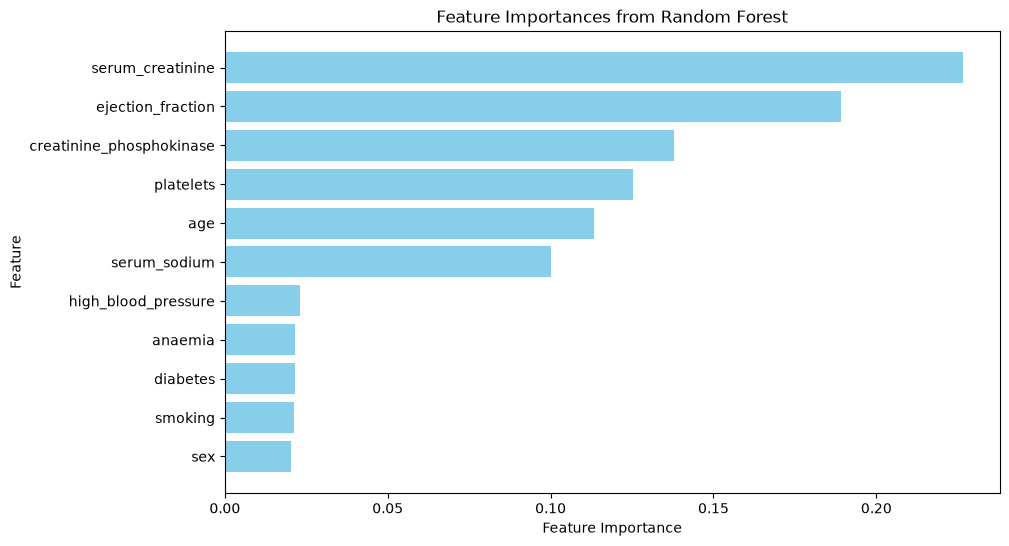

In [11]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_

feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

print(feature_importances_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

## Does Feature Selection Actually Help?

Now we test whether selecting only the top features improves model performance.

Experiment:
- Model trained on top 2 features `ejection_fraction` and `serum_creatinine` (selected by Lasso)
- Model trained on all 11 features (no selection)

What to look for: If the selected features give equal or better F1/accuracy with fewer inputs, the selection was successful. This is especially important on small datasets where irrelevant features hurt generalization.

In [12]:
# model trained on top 2 features
selected_features = feature_names[abs(B2) >= 0.05]
print(f'Features used: {selected_features}')

X_train_top_features = X_train.loc[:, selected_features]
X_test_top_features = X_test.loc[:, selected_features]

model = RandomForestClassifier()
model.fit(X_train_top_features, y_train)
preds = model.predict(X_test_top_features)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

Features used: Index(['ejection_fraction', 'serum_creatinine'], dtype='str')
Accuracy: 0.8
Precision: 0.72
Recall: 0.6206896551724138
F1-Score: 0.6666666666666666


In [13]:
# model with no feature selection
model = RandomForestClassifier()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

Accuracy: 0.7666666666666667
Precision: 0.6538461538461539
Recall: 0.5862068965517241
F1-Score: 0.6181818181818182
